
Iteration 1
Centroids:
 [[5.17142857 3.17142857]
 [5.5        4.2       ]
 [6.45       2.95      ]]

Iteration 2
Centroids:
 [[4.8   3.05 ]
 [5.3   4.   ]
 [6.2   3.025]]

Iteration 3
Centroids:
 [[4.8   3.05 ]
 [5.3   4.   ]
 [6.2   3.025]]

Converged!


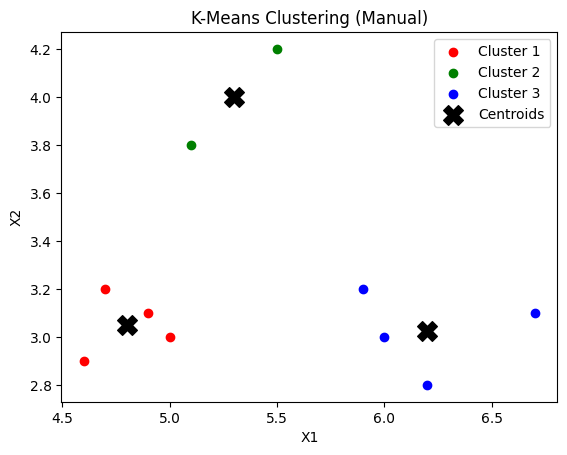

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Dataset
X = np.array([
    [5.9,3.2],[4.6,2.9],[6.2,2.8],[4.7,3.2],[5.5,4.2],
    [5.0,3.0],[4.9,3.1],[6.7,3.1],[5.1,3.8],[6.0,3.0]
])

# Step 2: Initial centroids
centroids = np.array([
    [6.2, 3.2],  # red
    [6.6, 3.7],  # green
    [6.5, 3.0]   # blue
])

colors = ['red', 'green', 'blue']

def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, None] - centroids, axis=2)
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, k):
    return np.array([X[labels == i].mean(axis=0) for i in range(k)])

# Step 3: Run K-means manually
k = 3
for iteration in range(10):
    labels = assign_clusters(X, centroids)
    new_centroids = update_centroids(X, labels, k)

    print(f"\nIteration {iteration+1}")
    print("Centroids:\n", new_centroids)

    # Stop if converged
    if np.allclose(centroids, new_centroids):
        print("\nConverged!")
        break

    centroids = new_centroids

# Step 4: Final Plot
plt.figure()

for i in range(k):
    plt.scatter(X[labels == i][:,0],
                X[labels == i][:,1],
                color=colors[i],
                label=f"Cluster {i+1}")

# Plot centroids
plt.scatter(centroids[:,0], centroids[:,1],
            marker='X', s=200, color='black', label='Centroids')

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("K-Means Clustering (Manual)")
plt.legend()
plt.show()